*Updated Daily*

## Imports and Data Download

In [1]:
import sys
sys.path.append('/kaggle/input/pip-install-datatable/packages/')
from datatable import dt, f, g, sort, join, by
import numpy as np
import matplotlib.pyplot as plt

!wget --content-disposition https://www.kaggle.com/competitions/52784/leaderboard/download/public
!wget --content-disposition https://www.kaggle.com/competitions/52784/leaderboard/download/private
DT_public = dt.fread("*public*.zip")
DT_private = dt.fread("*private*.zip")

--2023-08-15 00:24:38--  https://www.kaggle.com/competitions/52784/leaderboard/download/public
Resolving www.kaggle.com (www.kaggle.com)... 35.244.233.98
Connecting to www.kaggle.com (www.kaggle.com)|35.244.233.98|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 206470 (202K) [application/zip]
Saving to: ‘icr-identify-age-related-conditions-publicleaderboard-2023-08-15T00:24:38.zip’

icr-identify-age-re 100%[===================>] 201.63K   898KB/s    in 0.2s    

2023-08-15 00:24:39 (898 KB/s) - ‘icr-identify-age-related-conditions-publicleaderboard-2023-08-15T00:24:38.zip’ saved [206470/206470]

--2023-08-15 00:24:40--  https://www.kaggle.com/competitions/52784/leaderboard/download/private
Resolving www.kaggle.com (www.kaggle.com)... 35.244.233.98
Connecting to www.kaggle.com (www.kaggle.com)|35.244.233.98|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 209950 (205K) [application/zip]
Saving to: ‘icr-identify-age-related-conditions-pr

## Some Statistics

In [2]:
teams_total = DT_public.nrows
teams_multi = DT_public[:, dt.re.match(f.TeamMemberUserNames, ".*,.*")].sum1()
teams_solo = teams_total - teams_multi
subs_firstlast = DT_public[:, f.LastSubmissionDate, dt.sort(f.LastSubmissionDate)][[0, -1], :].to_list()
subs_total = DT_public["SubmissionCount"].sum1()
subs_min = DT_public["SubmissionCount"].min1()
subs_max = DT_public["SubmissionCount"].max1()
subs_median = DT_public[:, dt.int8(dt.median(f.SubmissionCount))][0, 0]

print(f"Number of teams: {teams_total:,} ({teams_solo:,} solo/{teams_multi:,} multi)")
print()
print(f"Number of submissions: {subs_total:,}") 
print()
print(f"First submission: {subs_firstlast[0][0]}")
print()
print(f"Last submission: {subs_firstlast[0][1]}")
print()
print(f"Submissions per team: {subs_min}/{subs_max}/{subs_median} (min/max/median)")
print()

lbs = {"Public" : DT_public, "Private" : DT_private}

for lb_type, DT in lbs.items():
    score_min = DT["Score"].min1()
    score_max = DT["Score"].max1()
    score_median = DT[:, dt.median(f.Score)][0, 0]
    print(f"{lb_type} LB scores: {score_min}/{score_max}/{score_median} (min/max/median)")
    print()

Number of teams: 6,431 (5,921 solo/510 multi)

Number of submissions: 57,334

First submission: 2023-05-05 19:41:45

Last submission: 2023-08-10 23:57:26

Submissions per team: 1/91/5 (min/max/median)

Public LB scores: 0.0/30.9392/0.20777 (min/max/median)

Private LB scores: 0.30626/27.00618/0.55369 (min/max/median)



## LB Scores vs Number of Teams

Most frequent public score: 0.06613 by 922 teams



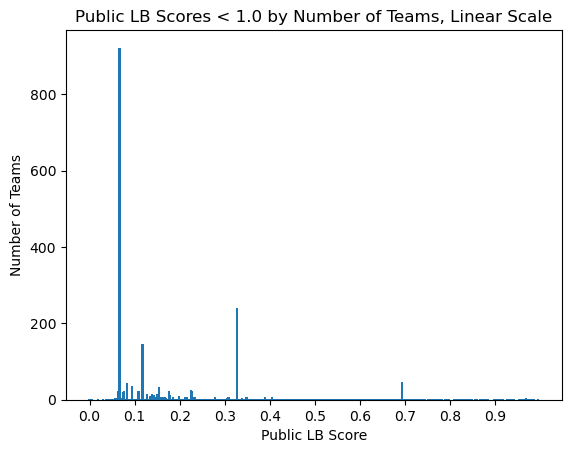

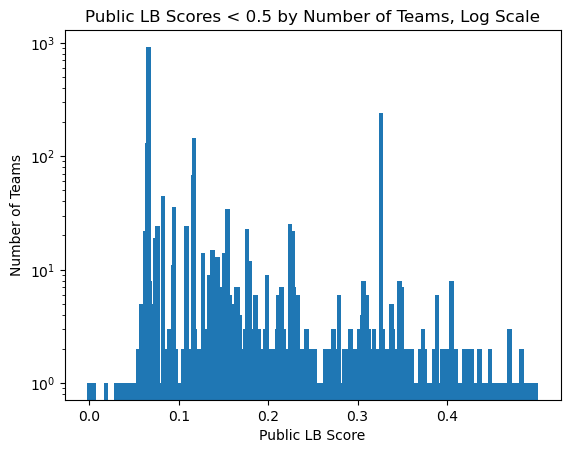

In [3]:
DT_grp = DT_public[:, dt.count(), by(f.Score)]
score, nteams = DT_grp[:, dt.first(f[:]), sort(-f.count)].to_list()
print(f"Most frequent public score: {score[0]} by {nteams[0]:,} teams")
print()

lb = DT_grp[f.Score < 1, :].to_list()
plt.bar(lb[0], lb[1], color ='tab:blue', width = 0.005)
plt.xlabel(f"Public LB Score")
plt.ylabel("Number of Teams")
plt.xticks(np.arange(0, 1, 0.1))
plt.title(f"Public LB Scores < 1.0 by Number of Teams, Linear Scale")
plt.show()

lb = DT_grp[f.Score < 0.5, :].to_list()
plt.bar(lb[0], lb[1], color ='tab:blue', width = 0.005)
plt.xlabel(f"Public LB Score")
plt.ylabel("Number of Teams")
plt.xticks(np.arange(0, 0.5, 0.1))
plt.yscale("log")
plt.title(f"Public LB Scores < 0.5 by Number of Teams, Log Scale")
plt.show()

Most frequent private score: 0.4816 by 290 teams



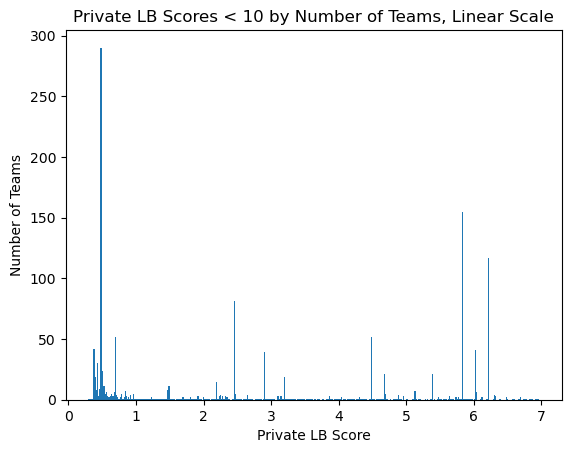

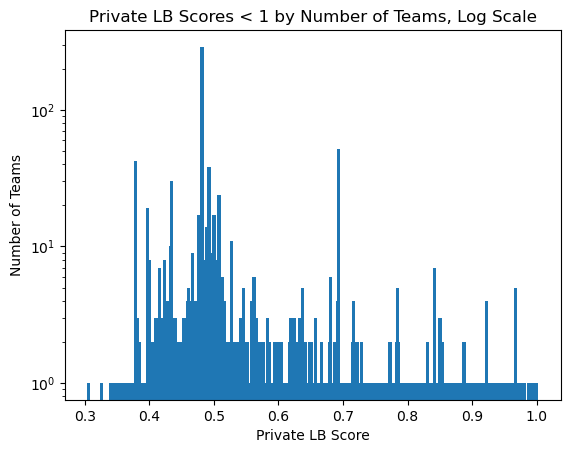

In [4]:
DT_grp = DT_private[:, dt.count(), dt.by(f.Score)]
score, nteams = DT_grp[:, dt.first(f[:]), sort(-f.count)].to_list()
print(f"Most frequent private score: {score[0]} by {nteams[0]:,} teams")
print()

lb = DT_grp[f.Score < 7, :].to_list()
plt.bar(lb[0], lb[1], color ='tab:blue', width = 0.02)
plt.xlabel(f"Private LB Score")
plt.ylabel("Number of Teams")
plt.title(f"Private LB Scores < 10 by Number of Teams, Linear Scale")
plt.show()

lb = DT_grp[f.Score < 1, :].to_list()
plt.bar(lb[0], lb[1], color ='tab:blue', width = 0.005)
plt.xlabel(f"Private LB Score")
plt.ylabel("Number of Teams")
plt.yscale("log")
plt.title(f"Private LB Scores < 1 by Number of Teams, Log Scale")
plt.show()

## Bonus: shake-up survivals

In [5]:
DT_public.key = ["TeamId"]
DT_private[f.Rank == g.Rank, f[:], join(DT_public)]

,Rank,TeamId,TeamName,LastSubmissionDate,Score,SubmissionCount,TeamMemberUserNames
,▪▪▪▪,▪▪▪▪,▪▪▪▪,▪▪▪▪▪▪▪▪,▪▪▪▪▪▪▪▪,▪▪▪▪,▪▪▪▪
0,0,10340829,sample_submission.csv,2023-05-05T19:41:45,0.69314,1,
1,4294,10602940,HongYuBaby,2023-06-25T04:35:10,0.72433,1,hongyubaby
2,6338,10669486,Shubhankar Sharma,2023-07-16T14:55:41,8.2988,1,shubhankarsharma73
3,6375,10375702,cmclean,2023-06-01T18:01:57,10.7998,7,caddis
4,6419,10667747,Jahom Culknife,2023-07-26T15:20:38,17.2694,1,jahomculknife
5,6420,10609316,Ahmed Ghobashi,2023-08-09T22:30:59,17.2694,4,ahmedghobashi
6,6421,10590307,momijiro,2023-08-10T01:50:32,17.2694,1,momijiro
7,6427,10679036,RoRonoA-TKO,2023-08-01T03:36:04,21.7722,1,tikoboss
8,6430,10654097,jakobjjk,2023-07-08T10:56:16,27.0062,1,jakobjjk


Besides the `sample_submission.csv` there are 8 teams who survived the massive shake-up, i.e. their rank didn't change when going from public to private LB. Unfortunately, all these teams are ranked somewhere in between 4294-th and 6430-th places.

In [6]:
DT_private[f.Score == g.Score, f[:], join(DT_public)]

,Rank,TeamId,TeamName,LastSubmissionDate,Score,SubmissionCount,TeamMemberUserNames
,▪▪▪▪,▪▪▪▪,▪▪▪▪,▪▪▪▪▪▪▪▪,▪▪▪▪▪▪▪▪,▪▪▪▪,▪▪▪▪
0,0,10340829,sample_submission.csv,2023-05-05T19:41:45,0.69314,1,
1,4140,10377324,Team +1,2023-05-12T02:44:08,0.69314,1,pakapro
2,4141,10381313,Niebal beally,2023-05-12T15:16:25,0.69314,1,niebal
3,4142,10386857,spoko,2023-05-14T18:06:01,0.69314,2,sergeydvindenko
4,4144,10407061,Dilly,2023-05-18T20:19:41,0.69314,3,dillythekid
5,4145,10391728,Pradeep Sapparapu,2023-05-26T10:35:59,0.69314,5,pradeepsapparapu
6,4146,10428294,AlexVasilyev,2023-05-23T09:45:03,0.69314,4,alexvasilyev
7,4147,10424213,Mohamed Kaouech,2023-05-26T19:29:33,0.69314,5,mohamedkaouech
8,4148,10430340,wuchen0405,2023-05-22T01:45:29,0.69314,1,wuchen0405


There are also 100 teams whose score didn't change when going from public to private. Most of them are constant `0`/`0.5`/`1` submissions.